In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
df 

Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Basic Infprmation 

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [15]:
df.shape

(7043, 21)

In [17]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [19]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

### Check Missing Values 

In [28]:
missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [29]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


### Check Duplicate Records 

In [31]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Fix TotalCharges 

In [34]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [35]:
print(df["TotalCharges"].isnull().sum())

11


In [36]:
df = df.dropna(subset=["TotalCharges"])

In [37]:
df = df.drop("customerID", axis=1)

In [38]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Target Variable Analyze 

In [46]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [48]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### Churn Visualization 

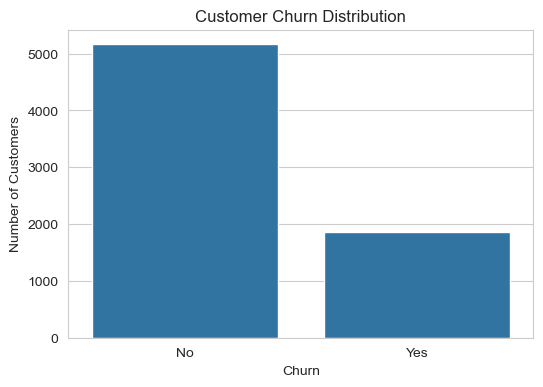

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Churn Pie Chart 

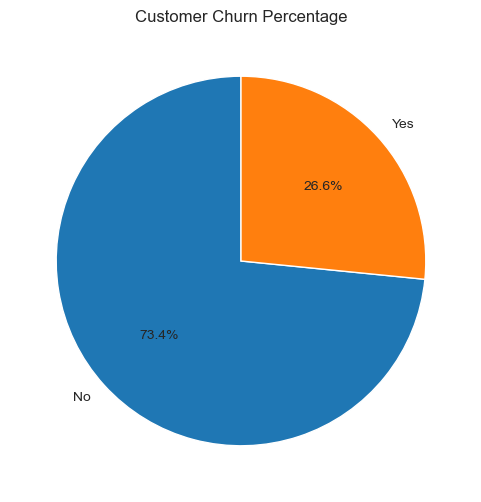

In [54]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

### Gender vs Churn 

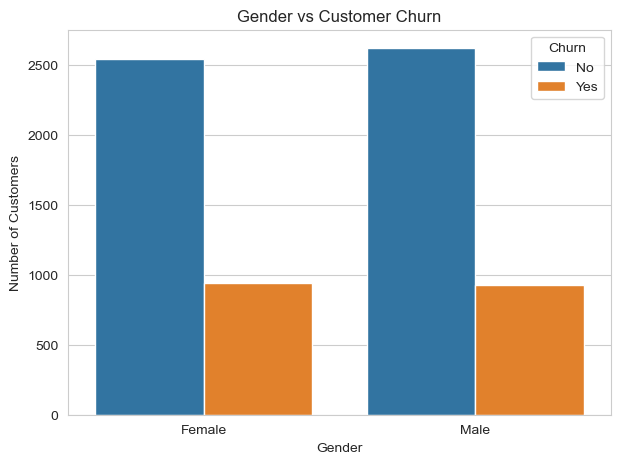

In [56]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Contract vs Churn 

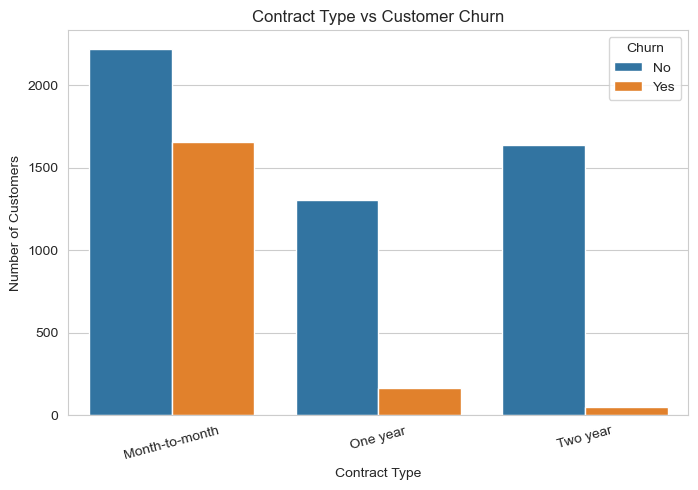

In [59]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Internet Service vs Churn 

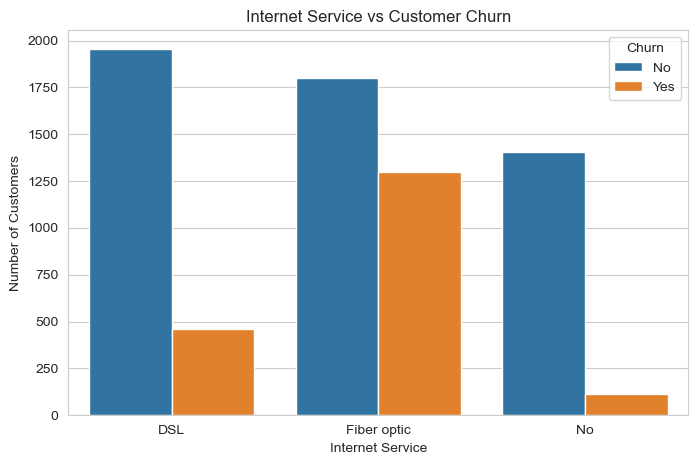

In [62]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Payment Method vs Churn 

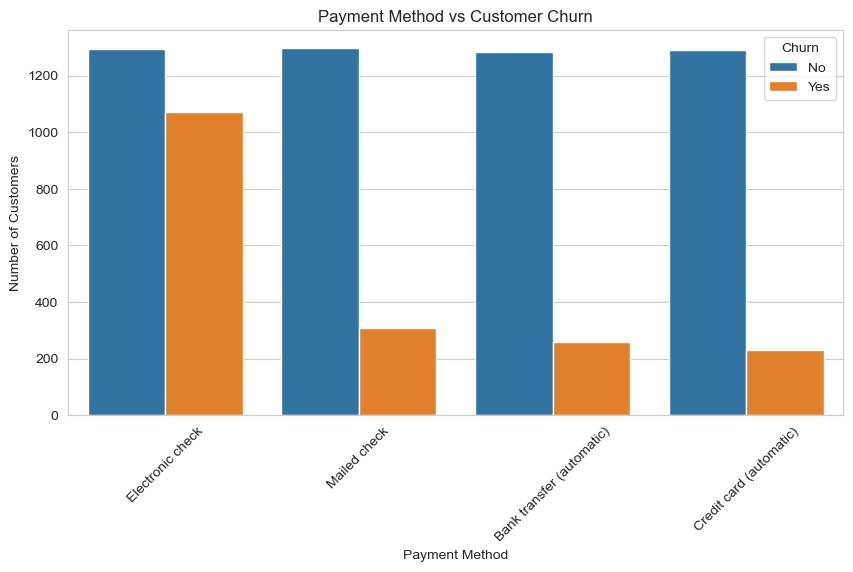

In [65]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

### Tenure Distribution 

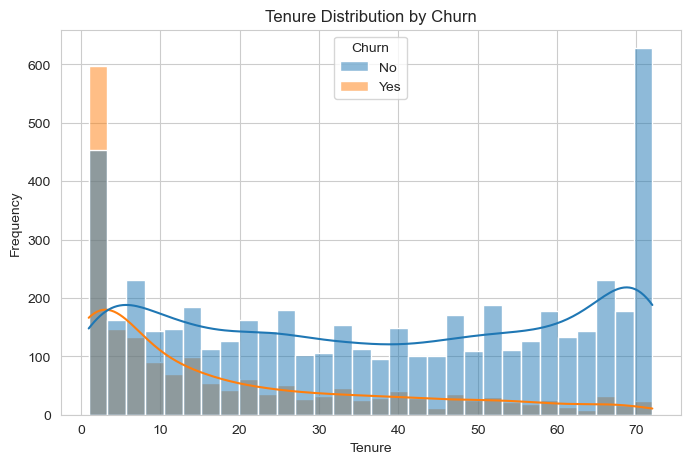

In [67]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.show()

### Monthly Charges 

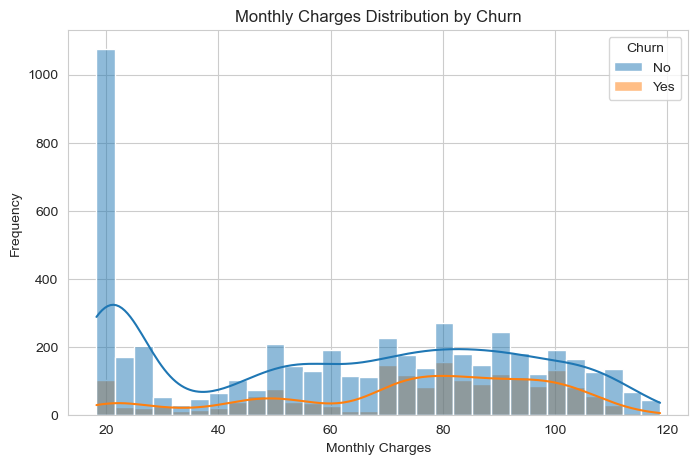

In [70]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

### Total Charges 

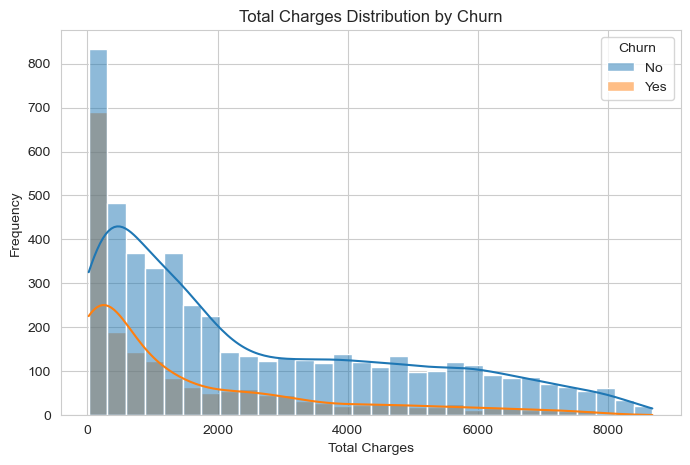

In [73]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Total Charges Distribution by Churn")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

### Box Plot 

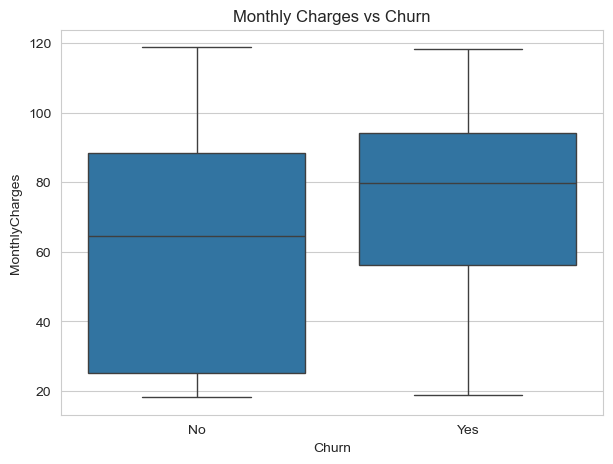

In [75]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

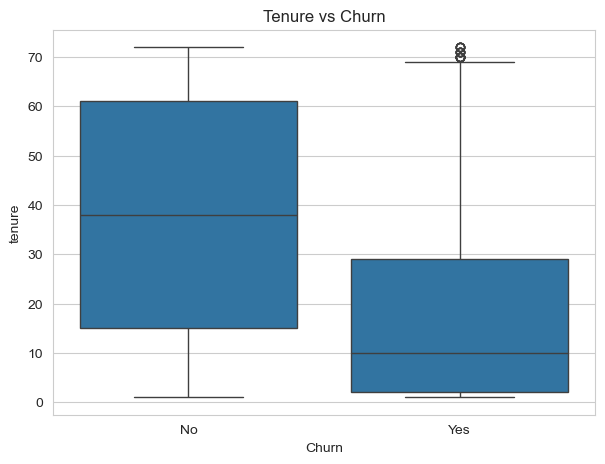

In [77]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

### Correlation Analysis 

In [79]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


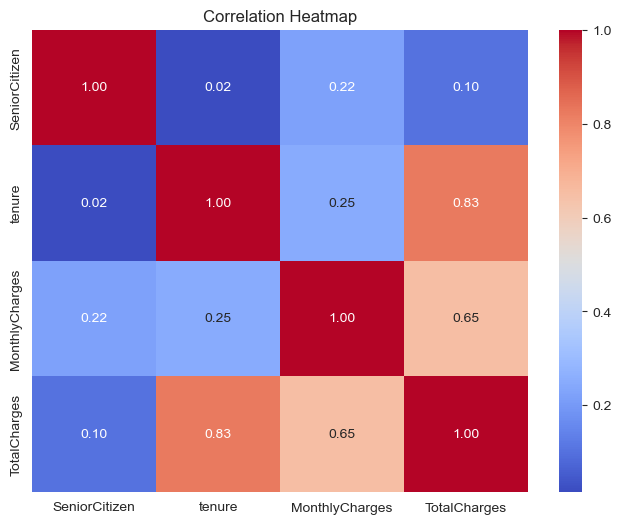

In [80]:
correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Convert Target 

In [82]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [84]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Convert Categorical Columns 

In [86]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [87]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [89]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [90]:
print("Encoded dataset shape:", df_encoded.shape)

Encoded dataset shape: (7032, 31)


In [91]:
X = df_encoded.drop("Churn", axis=1)

y = df_encoded["Churn"]

In [92]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


In [93]:
print("NaN values in Churn:", df_encoded["Churn"].isna().sum())

NaN values in Churn: 0


In [94]:
# Separate Features and Target

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows]
y = y.loc[valid_rows]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values in y:", y.isna().sum())

X shape: (7032, 30)
y shape: (7032,)
Missing values in y: 0


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


### Feature Scaling 

In [99]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Logistic Regression 

In [103]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [104]:
y_pred_lr = logistic_model.predict(
    X_test_scaled
)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

### Logistic Regression Evaluation 

In [107]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression")
print("-------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Logistic Regression
-------------------------
Accuracy : 0.8038379530916845
Precision: 0.6475903614457831
Recall   : 0.5748663101604278
F1 Score : 0.6090651558073654
ROC-AUC  : 0.8356727976766699


In [110]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Logistic Regression Confusion Matrix 

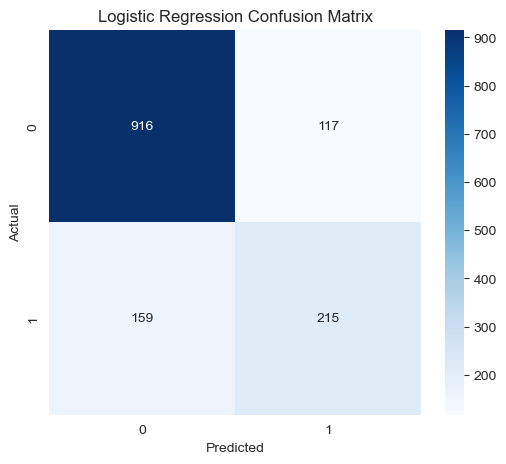

In [116]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Decision Tree 

In [123]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [124]:
y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(
    X_test
)[:, 1]

### Decision Tree Evaluation 

In [127]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print("Decision Tree")
print("-------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Decision Tree
-------------------------
Accuracy : 0.7782515991471215
Precision: 0.5807291666666666
Recall   : 0.5962566844919787
F1 Score : 0.5883905013192612
ROC-AUC  : 0.8195096572466881


### Random Forest 

In [132]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

random_forest.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [133]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(
    X_test
)[:, 1] 

### Random Forest Evaluation  

In [136]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest
-------------------------
Accuracy : 0.7910447761194029
Precision: 0.6438848920863309
Recall   : 0.4786096256684492
F1 Score : 0.549079754601227
ROC-AUC  : 0.838437187776633


### KNN 

In [138]:
knn_model = KNeighborsClassifier(
    n_neighbors=7
)

knn_model.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=7)

In [139]:
y_pred_knn = knn_model.predict(
    X_test_scaled
)

y_prob_knn = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

In [141]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_precision = precision_score(
    y_test,
    y_pred_knn
)

knn_recall = recall_score(
    y_test,
    y_pred_knn
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn
)

knn_auc = roc_auc_score(
    y_test,
    y_prob_knn
)

print("KNN")
print("-------------------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)
print("ROC-AUC  :", knn_auc)

KNN
-------------------------
Accuracy : 0.7491115849324804
Precision: 0.5278514588859416
Recall   : 0.5320855614973262
F1 Score : 0.5299600532623169
ROC-AUC  : 0.7811213898566555


### Compare All Models 

In [143]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ],
    
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        knn_precision
    ],
    
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        knn_recall
    ],
    
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        knn_f1
    ],
    
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc,
        knn_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510
2,Random Forest,0.791045,0.643885,0.478610,0.549080,0.838437
3,KNN,0.749112,0.527851,0.532086,0.529960,0.781121


### Plot Model Comparison 

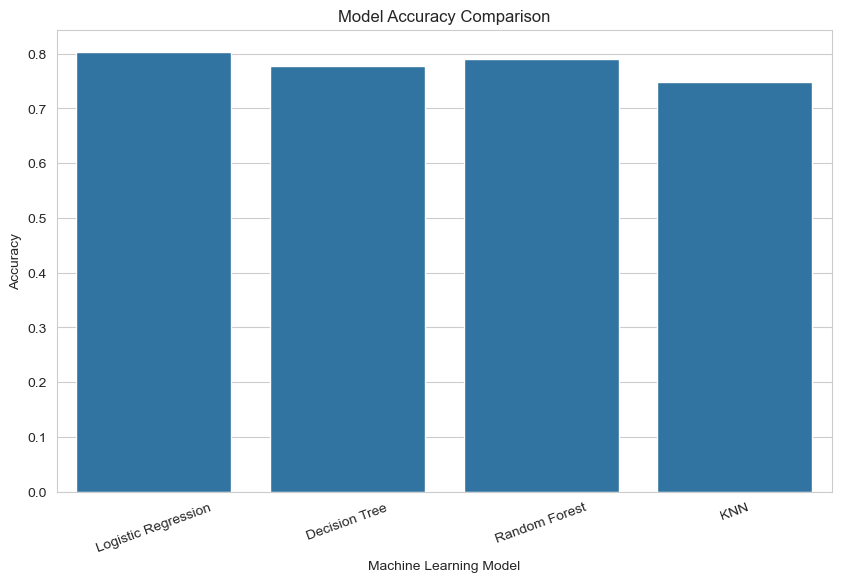

In [147]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

### ROC Curve 

In [150]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    y_prob_knn
)

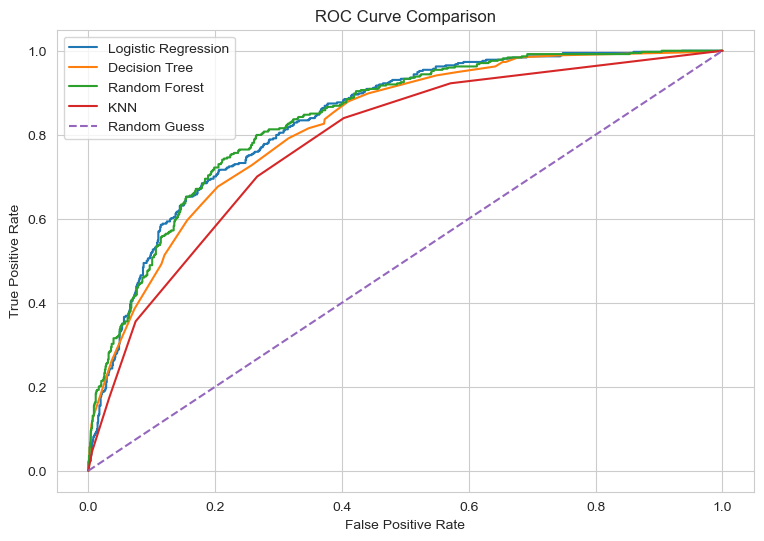

In [151]:
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label="Decision Tree"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label="KNN"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### Feature Importance 

In [153]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [154]:
top_features = feature_importance.head(15)

print(top_features)

                                 Feature  Importance
1                                 tenure    0.198541
3                           TotalCharges    0.149484
2                         MonthlyCharges    0.095816
10           InternetService_Fiber optic    0.083856
25                     Contract_Two year    0.074397
28        PaymentMethod_Electronic check    0.068474
13                    OnlineSecurity_Yes    0.040766
24                     Contract_One year    0.036723
19                       TechSupport_Yes    0.024699
16  DeviceProtection_No internet service    0.018251
18       TechSupport_No internet service    0.016399
20       StreamingTV_No internet service    0.015598
26                  PaperlessBilling_Yes    0.015500
12    OnlineSecurity_No internet service    0.015215
15                      OnlineBackup_Yes    0.013747


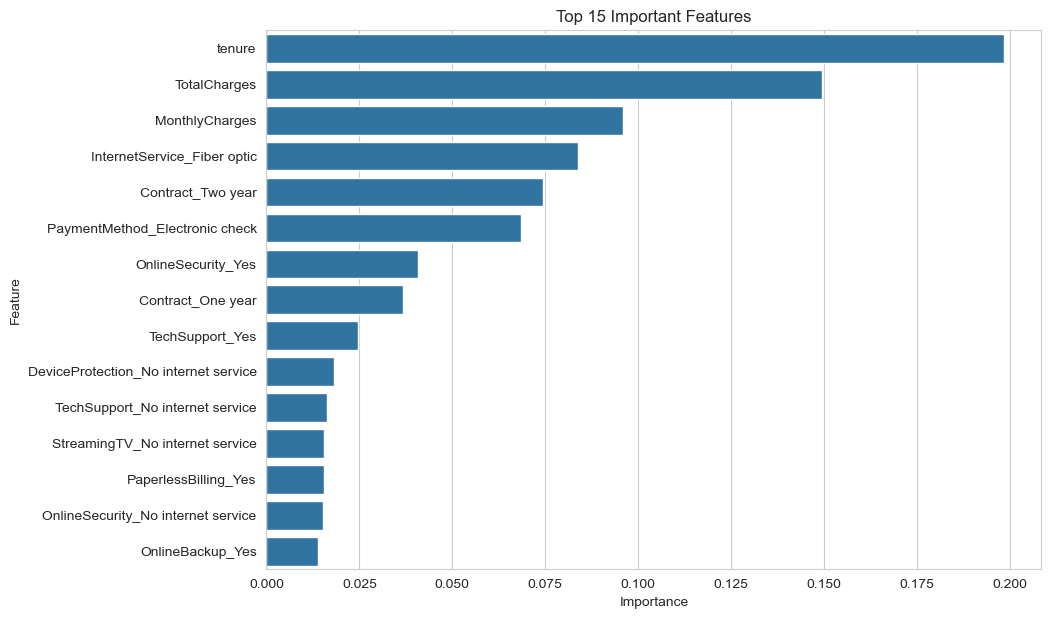

In [155]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

### Final Model 

In [157]:
final_model = random_forest

print("Final Model: Random Forest")

Final Model: Random Forest


### Final Sample Prediction 

In [161]:
sample_customer = X_test.iloc[[0]]

prediction = final_model.predict(
    sample_customer
)

probability = final_model.predict_proba(
    sample_customer
)[0][1]

In [162]:
if prediction[0] == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

print(
    "Churn Probability:",
    round(probability * 100, 2),
    "%"
)

Prediction: Customer is likely to STAY
Churn Probability: 2.56 %
